In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [37]:
# 1. Load the data from the CSV file into a pandas DataFrame
csv_file_path = '/Users/tvo/Documents/portfolio/college-notes/CSC 180/canada_per_capita_income.csv'

df = pd.read_csv(csv_file_path)
print("Original Data:")
print(df.head())
print("-" * 30)

Original Data:
   year       income
0  1970  3399.299037
1  1971  3768.297935
2  1972  4251.175484
3  1973  4804.463248
4  1974  5576.514583
------------------------------


In [38]:
# Check for Missing Data
missing_cols = df.isna().any()
if missing_cols.any():
    cols_with_missing = missing_cols[missing_cols].index
    for col in cols_with_missing:
        print(f"Data Missing in {col}")
else:
    print("No Missing Data in Any Column")

No Missing Data in Any Column


In [39]:
target = 'income'
features = [col for col in df.columns if col != target]

X = df[features] 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [40]:
# RandomForestRegressor
numeric_features = ['year']

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
]

preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor()) 
])

In [41]:
print("--- Model Results ---")
best_pipeline = grid_search.best_estimator_
model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']
importances = model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

print("Feature Importances:")
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

print("\n--- GridSearch Stats ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}") # Uses K-fold to predict
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")

--- Model Results ---
Feature Importances:
num__year: 1.0000

--- GridSearch Stats ---
Best parameters found: {'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 150}
Best cross-validation score: 0.9699
Test set score: 0.9787


In [42]:
# LinearRegrsssion w/out Dummy Variable
numeric_features = ['year']

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
]

preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()) 
])

pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
print(f"Test set score: {pipe.score(X_test, y_test):.4f}")

model = pipe.named_steps['model']
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

print("\nCoefficients:")
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.2f}")

Test set score: 0.8912

Coefficients:
num__year: 11518.70


In [44]:
data_to_predict = pd.DataFrame([
    {'year': 2030},
    {'year': 1965},
])

predictions_rf = grid_search.predict(data_to_predict)
predictions_lg = pipe.predict(data_to_predict)

for year, pred_rf, pred_lg in zip(data_to_predict['year'], predictions_rf, predictions_lg):
    print(f"\nFor the year {year}:")
    print(f"  - Random Forest Predicted Income: ${pred_rf:,.2f}")
    print(f"  - Linear Regression Predicted Income: ${pred_lg:,.2f}")


For the year 2030:
  - Random Forest Predicted Income: $37,392.20
  - Linear Regression Predicted Income: $49,921.96

For the year 1965:
  - Random Forest Predicted Income: $3,676.86
  - Linear Regression Predicted Income: $-3,619.22


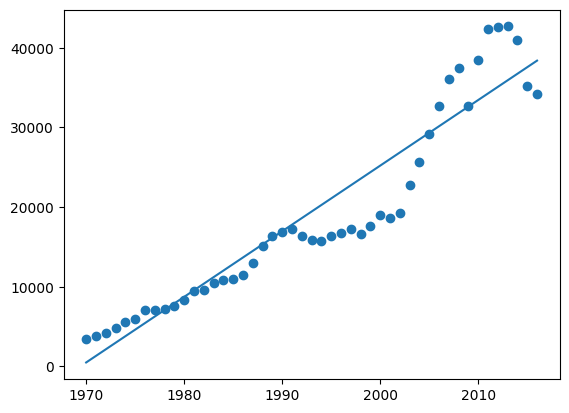

In [47]:
import matplotlib.pyplot as plt

y_pred = pipe.predict(X)
plt.scatter(x = df['year'], y=df['income'])
plt.plot(X, y_pred)

0.9799426689529015

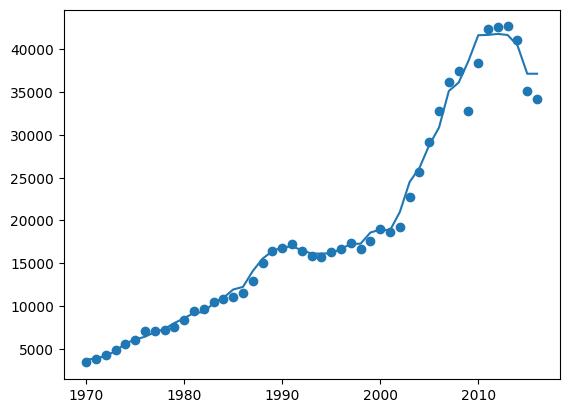

In [53]:
# RandomForestRegressor
numeric_features = ['year']

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
]
preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_jobs=-1, n_estimators=400)) 
])

pipe_rf.fit(X_train, y_train)

y_pred = pipe_rf.predict(X)

plt.scatter(x = df['year'], y=df['income'])
plt.plot(X, y_pred)
pipe_rf.score(X_test, y_test)

0.9773678182379898

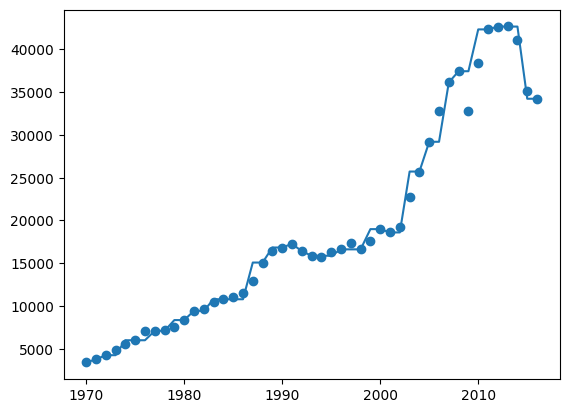

In [51]:
# Decision Tree Regressor
from sklearn import tree 

numeric_features = ['year']

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
]
preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', tree.DecisionTreeRegressor()) 
])

pipe_dt.fit(X_train, y_train)

y_pred = pipe_dt.predict(X)

plt.scatter(x = df['year'], y=df['income'])
plt.plot(X, y_pred)


pipe_dt.score(X_test, y_test)